In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:

file_path = "./global_superstore_2016(Orders).csv"
df = pd.read_csv(file_path, encoding="latin1", low_memory=False)

# 1. Clean currency strings into numeric floats
def clean_currency(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    is_neg = False
    if s.startswith("(") and s.endswith(")"):
        is_neg = True
        s = s[1:-1]
    elif "-" in s:
        is_neg = True
        s = s.replace("-", "")
    s = s.replace("$", "").replace(",", "").strip()
    try:
        n = float(s)
        return -n if is_neg else n
    except:
        return np.nan

df["Sales"] = df["Sales"].apply(clean_currency)
df["Profit"] = df["Profit"].apply(clean_currency)

# 2. Parse dates and engineer time-based features
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Year-Month"] = df["Order Date"].dt.to_period("M")

# 3. Add Profit Margin ratio
df["Profit Margin (%)"] = (df["Profit"] / df["Sales"]) * 100

print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)

Dataset shape: 51,290 rows, 29 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping Days,Order Year,Order Month,Order Year-Month,Profit Margin (%)
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.00,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.00,62.15,40.77,High,2,2014,11,2014-11,28.00
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.10,-288.77,923.63,Critical,2,2014,2,2014-02,-7.78
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.10,919.97,915.49,Medium,1,2014,10,2014-10,17.78


In [3]:
print("Duplicate rows:", df.duplicated(subset=["Order ID", "Product ID"]).sum())

# Missing values summary
missing = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df) * 100).round(2)
}).query("`Null Count` > 0")

print("\n--- Columns with Missing Values ---")
display(missing)

Duplicate rows: 42

--- Columns with Missing Values ---


,Null Count,Null %
Postal Code,41296,80.51


In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
overall_margin = (total_profit / total_sales) * 100

print("=" * 45)
print("       GLOBAL SUPERSTORE KPI SUMMARY         ")
print("=" * 45)
print(f"Total Revenue       : ${total_sales:,.2f}")
print(f"Total Profit        : ${total_profit:,.2f}")
print(f"Overall Margin      : {overall_margin:.2f}%")
print(f"Total Unique Orders : {total_orders:,}")
print(f"Unique Customers    : {total_customers:,}")
print(f"Average Order Value : ${total_sales / total_orders:,.2f}")
print("=" * 45)


num_cols = ["Sales", "Profit", "Quantity", "Discount", "Shipping Cost", "Shipping Days"]
display(df[num_cols].describe().T)

       GLOBAL SUPERSTORE KPI SUMMARY         
Total Revenue       : $12,642,507.25
Total Profit        : $1,467,456.67
Overall Margin      : 11.61%
Total Unique Orders : 25,728
Unique Customers    : 17,415
Average Order Value : $491.39


,count,mean,std,min,25%,50%,75%,max
Sales,51290.00,246.49,487.57,0.44,30.76,85.06,251.06,22638.48
Profit,51290.00,28.61,174.34,-6599.98,0.00,9.24,36.81,8399.98
Quantity,51290.00,3.48,2.28,1.00,2.00,3.00,5.00,14.00
Discount,51290.00,0.14,0.21,0.00,0.00,0.00,0.20,0.85
Shipping Cost,51290.00,26.48,57.25,1.00,2.61,7.79,24.45,933.57
Shipping Days,51290.00,3.97,1.73,0.00,3.00,4.00,5.00,7.00


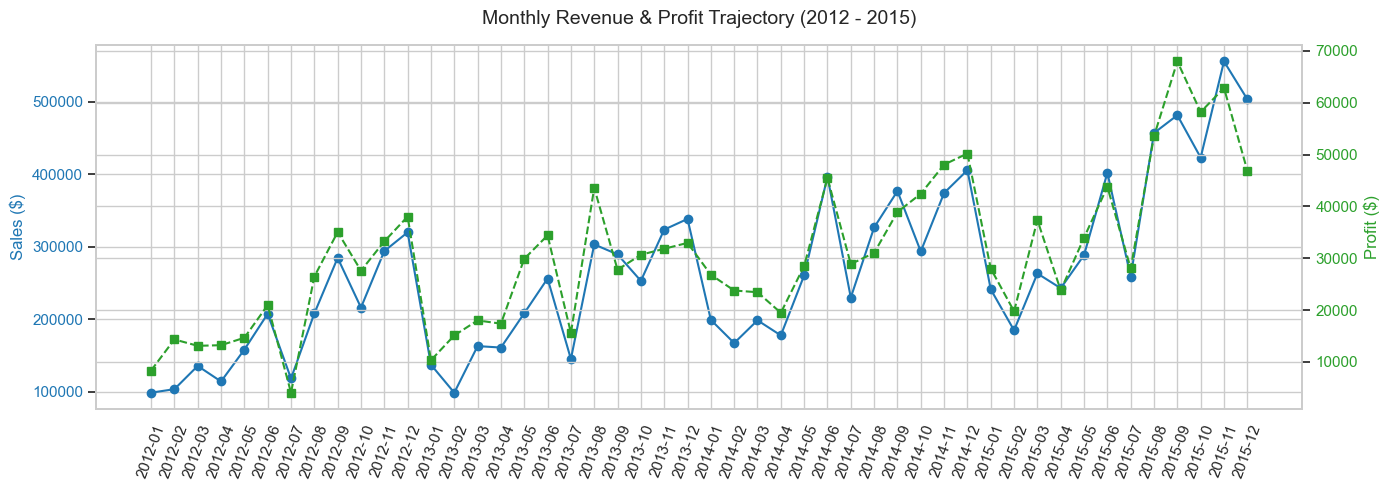

In [5]:

monthly_trend = df.groupby("Order Year-Month")[["Sales", "Profit"]].sum().reset_index()
monthly_trend["Order Year-Month"] = monthly_trend["Order Year-Month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(monthly_trend["Order Year-Month"], monthly_trend["Sales"], color="#1f77b4", marker="o", label="Sales ($)")
ax1.set_ylabel("Sales ($)", color="#1f77b4", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
plt.xticks(rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_trend["Order Year-Month"], monthly_trend["Profit"], color="#2ca02c", marker="s", linestyle="--", label="Profit ($)")
ax2.set_ylabel("Profit ($)", color="#2ca02c", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#2ca02c")

plt.title("Monthly Revenue & Profit Trajectory (2012 - 2015)", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

C:\Users\suman\AppData\Local\Temp\ipykernel_17268\2278365064.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_summary, x="Total_Profit", y="Sub-Category", palette=palette, ax=axes[1])


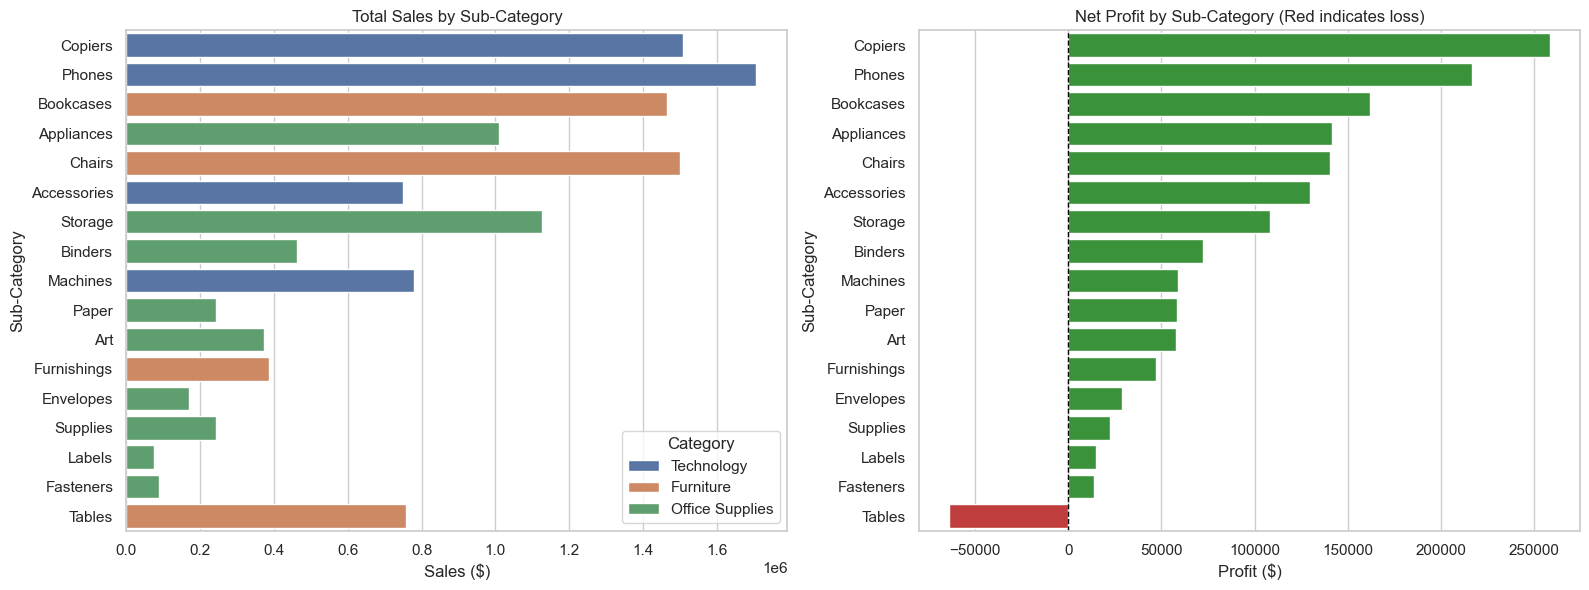

In [6]:
# Sub-category aggregation
subcat_summary = df.groupby(["Category", "Sub-Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index().sort_values(by="Total_Profit", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Sub-Category
sns.barplot(data=subcat_summary, x="Total_Sales", y="Sub-Category", hue="Category", dodge=False, ax=axes[0])
axes[0].set_title("Total Sales by Sub-Category")
axes[0].set_xlabel("Sales ($)")

# Profit by Sub-Category (Identifies loss-making product lines)
palette = ["#d62728" if x < 0 else "#2ca02c" for x in subcat_summary["Total_Profit"]]
sns.barplot(data=subcat_summary, x="Total_Profit", y="Sub-Category", palette=palette, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Net Profit by Sub-Category (Red indicates loss)")
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()

C:\Users\suman\AppData\Local\Temp\ipykernel_17268\2621140644.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_perf.index, y=market_perf["Margin"], palette="Blues_r", ax=ax[1])


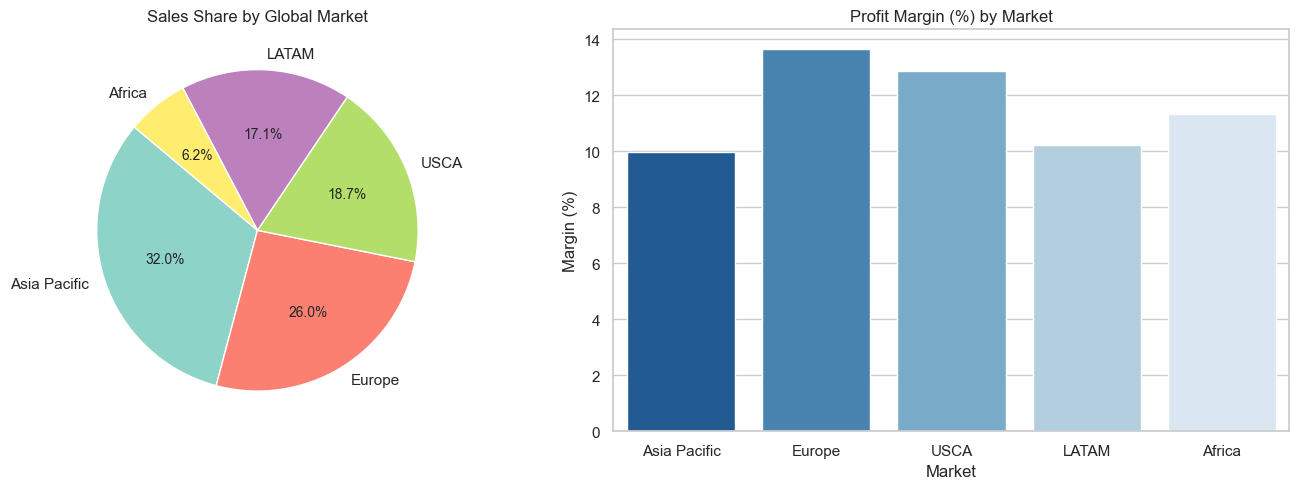

In [7]:
market_perf = df.groupby("Market").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Margin=("Profit", lambda x: (x.sum() / df.loc[x.index, "Sales"].sum()) * 100)
).sort_values(by="Sales", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Market Sales share
market_perf["Sales"].plot.pie(autopct="%.1f%%", ax=ax[0], startangle=140, cmap="Set3")
ax[0].set_ylabel("")
ax[0].set_title("Sales Share by Global Market")

# Market Profit Margin
sns.barplot(x=market_perf.index, y=market_perf["Margin"], palette="Blues_r", ax=ax[1])
ax[1].set_title("Profit Margin (%) by Market")
ax[1].set_ylabel("Margin (%)")
ax[1].set_xlabel("Market")

plt.tight_layout()
plt.show()

C:\Users\suman\AppData\Local\Temp\ipykernel_17268\3416961564.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_impact, x="Discount Bin", y="Avg_Profit", palette="vlag", ax=ax1)


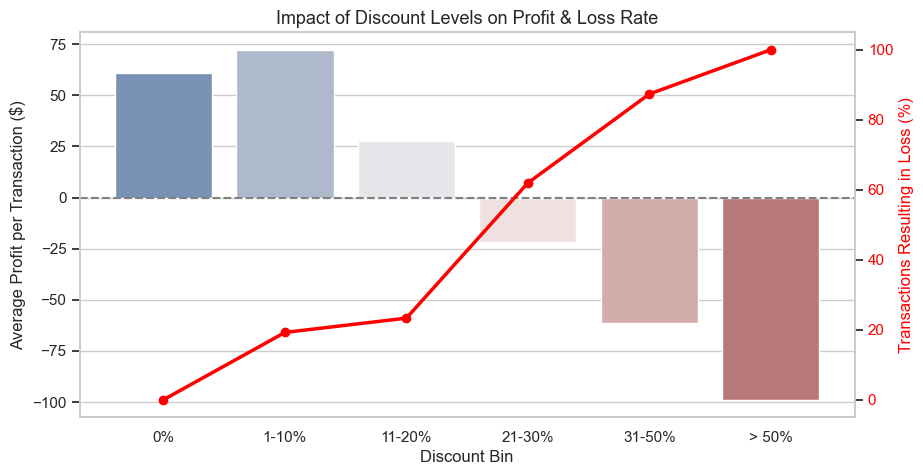

In [8]:
# Bin discounts to observe margin degradation
df["Discount Bin"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0.0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=["0%", "1-10%", "11-20%", "21-30%", "31-50%", "> 50%"]
)

discount_impact = df.groupby("Discount Bin", observed=False).agg(
    Order_Count=("Order ID", "count"),
    Avg_Profit=("Profit", "mean"),
    Total_Profit=("Profit", "sum"),
    Loss_Rate=("Profit", lambda x: (x < 0).mean() * 100)
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(data=discount_impact, x="Discount Bin", y="Avg_Profit", palette="vlag", ax=ax1)
ax1.set_ylabel("Average Profit per Transaction ($)")
ax1.axhline(0, color="gray", linestyle="--")

ax2 = ax1.twinx()
ax2.plot(discount_impact.index, discount_impact["Loss_Rate"], color="red", marker="o", linewidth=2.5, label="Loss Rate (%)")
ax2.set_ylabel("Transactions Resulting in Loss (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.grid(False)

plt.title("Impact of Discount Levels on Profit & Loss Rate", fontsize=13)
plt.show()

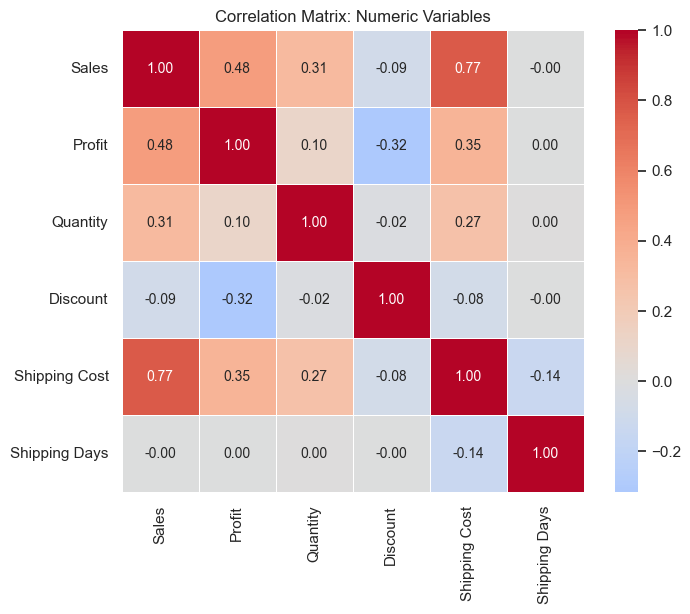

In [9]:
plt.figure(figsize=(8, 6))
corr = df[["Sales", "Profit", "Quantity", "Discount", "Shipping Cost", "Shipping Days"]].corr()

sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    square=True, 
    linewidths=0.5
)
plt.title("Correlation Matrix: Numeric Variables")
plt.show()